# Sentiment Analysis with pre-trained models and fine-tuning methods

Python version == 3.12.13

| Property | BERT-based models |
|---|---|
| Architecture | Encoder-only (discriminative) |
| Task fit for sentiment | Direct (classification head) |
| Inference speed | faster than ED models (single forward pass) |
| Fine-tuning efficiency | Lower — ideal for local machines |

---

## BERT-based model options

### 1. `bert-base-multilingual-cased` (mBERT)
 - **Params:** ~177M | **Languages:** 104
 - WordPiece tokenizer

### 2. `distilbert-base-multilingual-cased`
 - **Params:** ~135M | **Languages:** 104
 - Kafka Streaming

### 3. `xlm-roberta-base` (XLM-RoBERTa)
 - **Params:** ~278M | **Languages:** 100 
 - SentencePiece tokenizer 

## Import necessary packages and configurations

In [1]:
# Necessary imports
import os
import time
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

from collections import Counter
from datasets import Dataset, DatasetDict, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    pipeline,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    PeftModel,
)
import evaluate

from langdetect import detect, LangDetectException

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}") # My mac uses mps
print(f"CUDA available: {torch.cuda.is_available()}") # CUDA is added just in case

PyTorch version: 2.2.2
MPS available: True
CUDA available: False


In [2]:
# Data of combining cardiffnlp
raw_en = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(Counter(raw_en["train"]["label"]))

Counter({1: 20673, 2: 17849, 0: 7093})


In [3]:
# DATA_PATH = "/Users/julianyoo/Downloads/GitHub/machine_learning_project/synthetic_social_media_data.csv" # Kaggle data


# Baseline model for fine-tning
BASE_MODEL_NAME = "xlm-roberta-base"

# Stream model for Kafka
STREAM_MODEL_NAME  = "distilbert-base-multilingual-cased"

# Model names
MODELS = {
    "xlm-roberta"  : "xlm-roberta-base",
    "mbert"        : "bert-base-multilingual-cased",
    "distilbert-ml": "distilbert-base-multilingual-cased",
}

# Training Configuration
MAX_LENGTH = 128
BATCH_SIZE = 32
NUM_EPOCHS = 5
WEIGHT_DECAY = 0.01
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
TEST_SIZE = 0.15
VAL_SIZE = 0.10
SEED = 42

# LoRA Configuration
LORA_R = 16 # LoRA Rank 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.1
LORA_LR = 3e-4

# DistilBERT uses different attention layer names for LoRA
LORA_TARGETS = {
    "xlm-roberta"  : ["query", "value"],
    "mbert"        : ["query", "value"],
    "distilbert-ml": ["q_lin", "v_lin"],
}

# Output dir
FULL_FT_DIR = "./outputs/bert_fullft"
LORA_FT_DIR = "./outputs/bert_lora"
STREAM_MODEL_DIR = "./outputs/stream_model"
os.makedirs("./outputs", exist_ok=True)

# Device choice
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Active device: {DEVICE}")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Active device: mps


## Data load and pre-processing

In [4]:
_label_map = {0: "negative", 1: "neutral", 2: "positive"}

train_df = pd.DataFrame({
    "Text": raw_en["train"]["text"],
    "Sentiment": [_label_map[i] for i in raw_en["train"]["label"]]
})
val_df = pd.DataFrame({
    "Text": raw_en["validation"]["text"],
    "Sentiment": [_label_map[i] for i in raw_en["validation"]["label"]]
})
test_df = pd.DataFrame({
    "Text": raw_en["test"]["text"],
    "Sentiment": [_label_map[i] for i in raw_en["test"]["label"]]
})

for _df in [train_df, val_df, test_df]:
    _df["Text"] = _df["Text"].astype(str).str.strip()
    _df["Sentiment"] = _df["Sentiment"].astype(str).str.strip()

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(train_df["Sentiment"].value_counts())

Sentiment
neutral     20673
positive    17849
negative     7093
Name: count, dtype: int64


In [ ]:
# Kaggle data load and preprocessing
"""df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)"""

Raw shape: (2000, 10)
Columns: ['Post ID', 'Post Content', 'Sentiment Label', 'Number of Likes', 'Number of Shares', 'Number of Comments', 'User Follower Count', 'Post Date and Time', 'Post Type', 'Language']


,Post ID,Post Content,Sentiment Label,Number of Likes,Number of Shares,Number of Comments,User Follower Count,Post Date and Time,Post Type,Language
0,aa391375-7355-44b7-bcbf-97fb4e5a2ba3,Word who nor center everything better politica...,Neutral,157,243,64,4921,2024-01-10 00:14:21,video,fr
1,1c9ec98d-437a-48d9-9cba-bd5ad853c59a,Begin administration population good president...,Positive,166,49,121,612,2024-02-03 00:20:11,image,es
2,170e5b5b-1d9a-4d02-a957-93c4dbb18908,Thousand total sign. Agree product relationshi...,Positive,185,224,179,9441,2024-07-25 14:20:23,video,de


In [4]:
df = df_raw.rename(columns={
    "Post Content"   : "Text",
    "Sentiment Label": "Sentiment",
})

cols_to_drop = ["Post ID", "Number of Likes", "Number of Shares",
             "Number of Comments", "User Follower Count",
             "Post Date and Time", "Post Type"]

df =  df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Standardise the text
df["Text"] = df["Text"].astype(str).str.strip()
df["Sentiment"] = df["Sentiment"].astype(str).str.lower().str.strip()
df = df.dropna(subset=["Text", "Sentiment"])
df = df[df["Text"].str.len() > 0].reset_index(drop=True)

print(f"\nCleaned shape : {df.shape}")
print(f"\nSentiment distribution:")
print(df["Sentiment"].value_counts())
df.head(3)


Cleaned shape : (2000, 3)

Sentiment distribution:
Sentiment
neutral     682
negative    675
positive    643
Name: count, dtype: int64


,Text,Sentiment,Language
0,Word who nor center everything better politica...,neutral,fr
1,Begin administration population good president...,positive,es
2,Thousand total sign. Agree product relationshi...,positive,de


Since the dataset already contains language codes, skip langdetect

In [5]:
print("Language distribution (from dataset metadata):")
print(df["Language"].value_counts())

Language distribution (from dataset metadata):


NameError: name 'df' is not defined

In [5]:
# Multi-language distribution
lang_dist = df["Language"].value_counts()
print(lang_dist)
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(lang_dist.index, lang_dist.values,
       color=sns.color_palette("tab10", len(lang_dist)))
ax.set_title("Language Distribution in Dataset", fontsize=13)
ax.set_xlabel("Language Code")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

Number of classes: 3
label2id mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


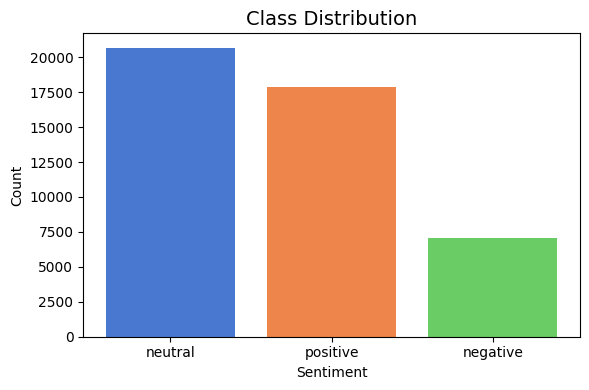

In [5]:
# Encode the labels
# unique_labels = sorted(df["Sentiment"].unique()) # Kaggle
unique_labels = sorted(train_df["Sentiment"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_LABELS = len(unique_labels)

# df["label"] = df["Sentiment"].map(label2id) # Kaggle

train_df["label"] = train_df["Sentiment"].map(label2id)
val_df["label"] = val_df["Sentiment"].map(label2id)
test_df["label"] = test_df["Sentiment"].map(label2id)

print(f"Number of classes: {NUM_LABELS}")
print(f"label2id mapping: {label2id}")

fig, ax = plt.subplots(figsize=(6, 4))
counts = train_df["Sentiment"].value_counts()
ax.bar(counts.index, counts.values,
       color=sns.color_palette("muted", len(counts)))
ax.set_title("Class Distribution", fontsize=14)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
# Stratified TTS the dataset
train_val_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["label"], random_state=SEED)
val_ratio_adjusted = VAL_SIZE / (1 - TEST_SIZE)
train_df, val_df = train_test_split(
    train_val_df, test_size=val_ratio_adjusted,
    stratify=train_val_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
 
print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)}   samples")
print(f"Test: {len(test_df)}  samples")

NameError: name 'df' is not defined

In [7]:
# Change into HF DatasetDict # Kaggle
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["Text", "label", "Language"]], preserve_index=False),
    "val": Dataset.from_pandas(val_df[["Text", "label", "Language"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["Text", "label", "Language"]], preserve_index=False)
})
print(f"\nDatasetDict: {dataset}")

KeyError: "['Language'] not in index"

In [7]:
# cardiffnlp
dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["Text", "label"]], preserve_index=False),
    "val": Dataset.from_pandas(val_df[["Text", "label"]], preserve_index=False),
    "test": Dataset.from_pandas(test_df[["Text", "label"]], preserve_index=False)
})

## Tokenise
RoBERTa uses SentencePiece BPE and BERT uses WordPiece.


In [8]:
# Load Tokeniser
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

sample_text = "The product launch was absolutely amazing! #BrandName"
tokens = tokenizer.tokenize(sample_text)
print(f"Sample text: {sample_text}")
print(f"Tokens: {tokens}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"Max length: {tokenizer.model_max_length}")

Sample text: The product launch was absolutely amazing! #BrandName
Tokens: ['▁The', '▁product', '▁launch', '▁was', '▁absolutely', '▁amazing', '!', '▁#', 'B', 'rand', 'Name']
Vocab size: 250,002
Max length: 512


In [9]:
# Tokenzed dataset
def make_tokenized_dataset(model_name: str) -> tuple[DatasetDict, AutoTokenizer]:
    """
    Build a fresh tokenized DatasetDict for any BERT-family model.
    Thisshould be called per model since each has its own tokenizer.
    """
    tok = AutoTokenizer.from_pretrained(model_name)
 
    ds = DatasetDict({
        "train": Dataset.from_pandas(train_df[["Text", "label"]], preserve_index=False),
        "val": Dataset.from_pandas(val_df[["Text", "label"]], preserve_index=False),
        "test" : Dataset.from_pandas(test_df[["Text", "label"]], preserve_index=False),
    })
 
    def tokenize_fn(batch):
        return tok(
            batch["Text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors=None,
        )
 
    tokenized_ds = ds.map(
        tokenize_fn,
        batched=True,
        batch_size=512,
        remove_columns=["Text"],
        desc=f"Tokenising [{model_name.split('/')[-1]}]",
    )
    tokenized_ds.set_format(
        type="torch", columns=["input_ids", "attention_mask", "label"]
    )
    return tokenized_ds, tok

tokenized, _ = make_tokenized_dataset(BASE_MODEL_NAME)
 
print(f"\nTokenized features : {tokenized['train'].features}")
print(f"Train sample shape : {tokenized['train']['input_ids'][0].shape}")

Tokenising [xlm-roberta-base]: 100%|██████████| 12284/12284 [00:00<00:00, 30971.48 examples/s]


Tokenized features : {'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
Train sample shape : torch.Size([128])


In [10]:
# For each language evaluation
test_with_lang = test_df.copy()

## Models
BERT-based models use linear classification head on top of [CLS] token represenation. Not generative.

The models output logit vectors of size num_labels, softmaxed into class probabilities.

In [11]:
# Load model with classification head
def load_base_model(model_name:str=BASE_MODEL_NAME) -> AutoModelForSequenceClassification:
    """
    This is to load XLM-RoBERTa with a fresh classification head.
    'num_labels', 'id2label', 'label2id' params are attached to the model config
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )
    return model.to(DEVICE)

base_model = load_base_model()

def count_params(model) -> str:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return (
        f"  Trainable: {trainable:>12,}\n"
        f"  Total: {total:>12,}\n"
        f"  Rate(%): {100 * trainable / total:.2f}%"
    )

print(count_params(base_model))

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Trainable:  278,045,955
  Total:  278,045,955
  Rate(%): 100.00%


In [12]:
# Accuracy metrics functions
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}

In [13]:
# Class weight calculation
# Inversely proportional to class frequency.
# Formula: w_c = total_samples / (num_classes × count_c)
label_counts  = train_df["label"].value_counts().sort_index()
class_weights = torch.tensor(
    [len(train_df) / (NUM_LABELS * label_counts[i]) for i in range(NUM_LABELS)],
    dtype=torch.float32,
).to(DEVICE)
 
print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"    {id2label[i]:<12} : {w:.4f}")

Class weights:
    negative     : 2.1437
    neutral      : 0.7355
    positive     : 0.8519


## N-Shot Inferences

### Zero-Shot on Baseline
Evaluate the pre-trained XLM-RoBERTa without any fine-tuning

In [14]:
base_model = load_base_model()
print(count_params(base_model))

def zero_shot_inference(model, tokenizer_, texts: list, device=DEVICE) -> list:
    model.eval()
    preds = []
    with torch.no_grad():
        for text in texts:
            enc = tokenizer_(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH, padding=True).to(device)
            logits = model(**enc).logits
            pred_id = logits.argmax(dim=-1).item()
            preds.append(id2label[pred_id])
    return preds

# Test with a sample
demo = min(10, len(test_df))
demo_texts = test_df["Text"].tolist()[:demo]
demo_labels = test_df["Sentiment"].tolist()[:demo]
base_preds = zero_shot_inference(base_model, tokenizer, demo_texts)

print("Zero-shot Baseline - XLM-RoBERTa")
for i, (text, true_lbl, pred_lbl) in enumerate(zip(demo_texts, demo_labels, base_preds)):
    status = "True" if pred_lbl == true_lbl else "False"
    print(f"[{i+1:02d}] {status} | True: {true_lbl:<12} | Pred: {pred_lbl:<12}")
    print(f"        Text: {text[:80]}" if len(text) > 80 else f"      Text: {text}")
    print()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Trainable:  278,045,955
  Total:  278,045,955
  Rate(%): 100.00%
Zero-shot Baseline - XLM-RoBERTa
[01] False | True: neutral      | Pred: negative    
        Text: @user @user what do these '1/2 naked pics' have to do with anything? They're not

[02] False | True: neutral      | Pred: negative    
      Text: OH: “I had a blue penis while I was this” [playing with Google Earth VR]

[03] False | True: neutral      | Pred: negative    
        Text: @user @user That's coming, but I think the victims are going to be Medicaid reci

[04] False | True: positive     | Pred: negative    
        Text: I think I may be finally in with the in crowd #mannequinchallenge  #grads2014 @u

[05] True | True: negative     | Pred: negative    
        Text: @user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, O

[06] False | True: neutral      | Pred: negative    
        Text: Savchenko now Saakashvili took drug test live on Ukraine TV. To prove they are n

[07] False | True

### Few-shot inferences

In [15]:
# Extracting CLS embeddings from BERT
def extract_cls_embeddings(model, tokenizer_, texts:list, device=DEVICE, batch_size:int=32) -> torch.Tensor:
    """
    Extrac [CLS] embeddings from the last hidden state. # Shape: (N, hidden_dim)
    """
    model.eval()
    all_embeddings = []

    # Access transformer
    if hasattr(model, "roberta"):
        encoder = model.roberta
    elif hasattr(model, "bert"):
        encoder = model.bert
    elif hasattr(model, "distilbert"):
        encoder = model.distilbert
    else:
        raise ValueError("Unknown model architecture.")

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i: i+batch_size]
            enc = tokenizer_(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=MAX_LENGTH).to(device)
            outputs = encoder(**enc)
            # [CLS] token is position 0 in the seq
            cls_emb = outputs.last_hidden_state[:, 0, :] # (batch, hidden)
            all_embeddings.append(cls_emb.cpu())

    return torch.cat(all_embeddings, dim=0)

In [16]:
# Classifiers for k-shot settings
def build_prototypes(model, tokenizer_, support_df:pd.DataFrame, k_shots:int) -> tuple[torch.Tensor, list]:
    """
    N samples per class from support_df, extract embeddings, and compute per-class centroids.

    Returns:
    prototypes: Tensor (num_classes, hidden_dim) - class centroids
    proto_labels: list of label strings in prototype order
    """
    class_embeddings = {}
    for label_str in unique_labels:
        class_rows = support_df[support_df["Sentiment"] == label_str]
        n_sample   = min(k_shots, len(class_rows))
        sample     = class_rows.sample(n=n_sample, random_state=SEED)
        embs       = extract_cls_embeddings(model, tokenizer_, sample["Text"].tolist())
        class_embeddings[label_str] = embs.mean(dim=0)  # Centroid

    proto_labels = list(class_embeddings.keys())
    prototypes   = torch.stack([class_embeddings[l] for l in proto_labels])
    return prototypes, proto_labels

# Predict the class from the query texts by cosine similarity
def prototype_predict(model, tokenizer_, query_texts: list, prototypes: torch.Tensor, proto_labels: list) -> list:
    query_embs = extract_cls_embeddings(model, tokenizer_, query_texts)  # (N, H)

    # Normalise both query and prototypes for cosine sim
    q_norm = torch.nn.functional.normalize(query_embs, dim=-1)
    p_norm = torch.nn.functional.normalize(prototypes, dim=-1)

    similarities = q_norm @ p_norm.T # (N, num_classes)
    pred_indicies = similarities.argmax(dim=-1).tolist()
    return [proto_labels[i] for i in pred_indicies]

In [17]:
few_shot_results = {}
query_texts = test_df["Text"].tolist()[:50] # Query set
query_labels = test_df["Sentiment"].tolist()[:50]

# Support_df is the copy of train data
support_df = train_df.copy()

for k in [1, 3, 5]:
    prototypes, proto_labels = build_prototypes(base_model, tokenizer, support_df, k_shots=k)
    preds = prototype_predict(base_model, tokenizer, query_texts, prototypes, proto_labels)
    acc   = accuracy_score(query_labels, preds)
    few_shot_results[f"{k}-shot"] = acc

    print(f"  {k}-SHOT PROTOTYPE INFERENCE  (Accuracy: {acc:.4f})")
    for j in range(min(5, len(query_texts))):
        status = "True" if preds[j] == query_labels[j] else "False"
        print(f"    [{j+1}] {status} True: {query_labels[j]:<12} | Pred: {preds[j]:<12}")
        print(f"        Text: {query_texts[j][:80]}")
    print()

print("\nFew-Shot Summary:")
for k_str, acc in few_shot_results.items():
    print(f"  {k_str}: {acc:.4f} accuracy")

  1-SHOT PROTOTYPE INFERENCE  (Accuracy: 0.2000)
    [1] False True: neutral      | Pred: positive    
        Text: @user @user what do these '1/2 naked pics' have to do with anything? They're not
    [2] False True: neutral      | Pred: positive    
        Text: OH: “I had a blue penis while I was this” [playing with Google Earth VR]
    [3] False True: neutral      | Pred: positive    
        Text: @user @user That's coming, but I think the victims are going to be Medicaid reci
    [4] False True: positive     | Pred: neutral     
        Text: I think I may be finally in with the in crowd #mannequinchallenge  #grads2014 @u
    [5] False True: negative     | Pred: positive    
        Text: @user Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, O

  3-SHOT PROTOTYPE INFERENCE  (Accuracy: 0.2600)
    [1] True True: neutral      | Pred: neutral     
        Text: @user @user what do these '1/2 naked pics' have to do with anything? They're not
    [2] False Tr

1 shot gives us the best accuracy but 0.36 ...

## Full fine-tuning

Instead of a general Trainer, FocalLossTrainer was used. ((1 - pt)^γ × CE). This is for the model is confidently predicting "negative" for every sample, `pt` is high and `(1 - pt)^2` shrinks the loss nearly to zero. The model gets nearly no reward for the easy collapse strategy.

In [18]:
class WeightedTrainer(Trainer):
    """
    CrossEntropyLoss with inverse-frequency class weights.
    """
    def __init__(self, *args, class_weights: torch.Tensor, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
 
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [19]:
class FocalLossTrainer(Trainer):
    """
    Focal Loss with optional class weights.
    gamma=2 down-weights easy/confident predictions so the model
    cannot exploit single-class collapse to minimise loss.
    """
    def __init__(self, *args, gamma: float = 2.0,
                 class_weights: torch.Tensor = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.gamma         = gamma
        self.class_weights = class_weights
 
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
 
        ce_fn   = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
            if self.class_weights is not None else None,
            reduction="none",
        )
        ce_loss = ce_fn(logits, labels)
        pt      = torch.exp(-ce_loss)
        loss    = ((1 - pt) ** self.gamma * ce_loss).mean()
 
        return (loss, outputs) if return_outputs else loss

In [26]:
# Full fine-tuning arguments (config) for MPS (Apple Silicon)
def run_full_finetune(model_key: str, model_name: str, tokenized_ds: DatasetDict) -> dict:
    print(f"    Full fine-tuning: {model_key} ({model_name})")

    model = load_base_model(model_name)
    out_dir = f"./outputs/{model_key}_fullft"
    os.makedirs(out_dir, exist_ok=True)

    print(count_params(model))

    args = TrainingArguments(
        output_dir = out_dir,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE * 2,
        learning_rate = LEARNING_RATE,
        weight_decay = WEIGHT_DECAY,
        warmup_ratio = WARMUP_RATIO,
        max_grad_norm = 1.0,
        eval_strategy = "steps",
        eval_steps = 300,
        save_strategy = "steps",
        save_steps = 300,
        load_best_model_at_end = True,
        metric_for_best_model = "f1_macro",
        greater_is_better = True,
        logging_steps = 20,
        report_to = "none", # Disable wandb/tensorboard - can use wandb
        seed = SEED,
        fp16 = False, # MPS does not support fp16 training
        bf16 = False, # bfloat16 not supported on MPS trainer
        dataloader_num_workers = 0, # Required for MPS stability
        push_to_hub = False
    )

    trainer = FocalLossTrainer(
        model = model,
        args = args,
        train_dataset = tokenized_ds["train"],
        eval_dataset = tokenized_ds["val"],
        compute_metrics = compute_metrics,
        gamma = 2.0,
        class_weights = class_weights,
        callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    print(f"    Training time : {time.time() - t0:.0f}s")

    trainer.save_model(f"{out_dir}/best")
 
    test_res = trainer.evaluate(tokenized_ds["test"])
    pred_out = trainer.predict(tokenized_ds["test"])
    pred_ids = np.argmax(pred_out.predictions, axis=-1)
    true_ids = pred_out.label_ids

    print(f"\n  Test Accuracy : {test_res['eval_accuracy']:.4f}")
    print(f"  Test F1-Macro : {test_res['eval_f1_macro']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(true_ids, pred_ids, target_names=unique_labels))
 
    return {
        "model_key"   : model_key,
        "method"      : "Full FT",
        "test_results": test_res,
        "pred_ids"    : pred_ids,
        "true_ids"    : true_ids,
    }

## PEFT/ LoRA Fine-tuning
LoRA(Low-Rank Adaptation) freezes the pre-trained weights and injects quite smaller trainable rank-decomposition
matrices into the attention layers.

Class weights (WeightTrainer) was used. Since LoRA has a fewer params, focal loss might be aggressive.

In [27]:
def run_lora_finetune(model_key: str, model_name: str, tokenized_ds: DatasetDict) -> dict:
    print(f"    LoRA Fine-tuning: {model_key} ({model_name})")

    base = load_base_model(model_name)
    out_dir = f"./outputs/{model_key}_lora"
    os.makedirs(out_dir, exist_ok=True)

    cfg = LoraConfig(
        r = LORA_R,
        lora_alpha = LORA_ALPHA,
        target_modules = LORA_TARGETS[model_key],
        lora_dropout = LORA_DROPOUT,
        bias = "none",
        task_type = TaskType.SEQ_CLS, # Sequence classification (not SEQ_2_SEQ)
        inference_mode = False,
    )
    model = get_peft_model(base, cfg)
 
    print(count_params(model))
    model.print_trainable_parameters()

    args = TrainingArguments(
        output_dir = out_dir,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE * 2,
        learning_rate = LORA_LR,
        weight_decay = WEIGHT_DECAY,
        warmup_ratio = WARMUP_RATIO,
        max_grad_norm = 1.0,
        eval_strategy = "steps",
        eval_steps = 300,
        save_strategy = "steps",
        save_steps = 300,
        load_best_model_at_end = True,
        metric_for_best_model = "f1_macro",
        greater_is_better = True,
        logging_steps = 20,
        report_to = "none",
        seed = SEED,
        fp16 = False,
        bf16 = False,
        dataloader_num_workers = 0,
        push_to_hub = False,
    )

    trainer = WeightedTrainer(
        model = model,
        args = args,
        train_dataset = tokenized_ds["train"],
        eval_dataset = tokenized_ds["val"],
        compute_metrics = compute_metrics,
        class_weights = class_weights,
        callbacks = [EarlyStoppingCallback(early_stopping_patience=2)],
    )

    t0 = time.time()
    trainer.train()
    print(f"    Training time : {time.time() - t0:.0f}s")

    model.save_pretrained(f"{out_dir}/adapters")
 
    test_res = trainer.evaluate(tokenized_ds["test"])
    pred_out = trainer.predict(tokenized_ds["test"])
    pred_ids = np.argmax(pred_out.predictions, axis=-1)
    true_ids = pred_out.label_ids

    print(f"\n  Test Accuracy : {test_res['eval_accuracy']:.4f}")
    print(f"    Test F1-Macro : {test_res['eval_f1_macro']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(true_ids, pred_ids, target_names=unique_labels))
 
    return {
        "model_key": model_key,
        "method": "LoRA",
        "test_results": test_res,
        "pred_ids": pred_ids,
        "true_ids": true_ids,
    }

### Comparison of three models

In [29]:
all_results = []
 
for model_key, model_name in MODELS.items():
    print(f"\nMODEL : {model_key.upper()}")
    print(f"    {model_name}")
 
    tokenized_ds, _ = make_tokenized_dataset(model_name)
 
    all_results.append(run_lora_finetune(model_key, model_name, tokenized_ds))
    #all_results.append(run_full_finetune(model_key, model_name, tokenized_ds))
 
    if DEVICE.type == "mps":
        torch.mps.empty_cache()


MODEL : XLM-ROBERTA
    xlm-roberta-base


Tokenising [xlm-roberta-base]: 100%|██████████| 12284/12284 [00:00<00:00, 29702.28 examples/s]


    LoRA Fine-tuning: xlm-roberta (xlm-roberta-base)


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Trainable:    1,182,723
  Total:  279,228,678
  Rate(%): 0.42%
trainable params: 1,182,723 || all params: 279,228,678 || trainable%: 0.4236


...

{'eval_loss': 0.7203654050827026, 'eval_accuracy': 0.6585, 'eval_f1_macro': 0.6471235922844197, 'eval_runtime': 6.7237, 'eval_samples_per_second': 297.453, 'eval_steps_per_second': 4.759, 'epoch': 2.73}


                                                     
 55%|█████▍    | 3900/7130 [16:25<13:36,  3.96it/s]s]


{'train_runtime': 985.6099, 'train_samples_per_second': 231.405, 'train_steps_per_second': 7.234, 'train_loss': 0.7686138162857447, 'epoch': 2.73}
    Training time : 986s


100%|██████████| 192/192 [00:41<00:00,  4.68it/s]


  Test Accuracy : 0.6338
    Test F1-Macro : 0.6332

  Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.77      0.67      3972
     neutral       0.73      0.52      0.61      5937
    positive       0.56      0.70      0.62      2375

    accuracy                           0.63     12284
   macro avg       0.63      0.66      0.63     12284
weighted avg       0.65      0.63      0.63     12284



In [30]:
all_results = []
 
for model_key, model_name in MODELS.items():
    print(f"\nMODEL : {model_key.upper()}")
    print(f"    {model_name}")
 
    tokenized_ds, _ = make_tokenized_dataset(model_name)
 
    #all_results.append(run_lora_finetune(model_key, model_name, tokenized_ds))
    all_results.append(run_full_finetune(model_key, model_name, tokenized_ds))
 
    if DEVICE.type == "mps":
        torch.mps.empty_cache()


MODEL : XLM-ROBERTA
    xlm-roberta-base


Tokenising [xlm-roberta-base]: 100%|██████████| 12284/12284 [00:00<00:00, 31995.00 examples/s]
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


    Full fine-tuning: xlm-roberta (xlm-roberta-base)
  Trainable:  278,045,955
  Total:  278,045,955
  Rate(%): 100.00%


                                                     
 66%|██████▌   | 4715/7130 [1:33:06<09:26,  4.26it/s]

{'loss': 0.5465, 'grad_norm': 1.2295253276824951, 'learning_rate': 5.610098176718093e-07, 'epoch': 0.01}


...

{'eval_loss': 0.43479132652282715, 'eval_accuracy': 0.6815, 'eval_f1_macro': 0.6680864928411728, 'eval_runtime': 6.3996, 'eval_samples_per_second': 312.519, 'eval_steps_per_second': 5.0, 'epoch': 3.16}


                                                     
 63%|██████▎   | 4500/7130 [27:02<15:48,  2.77it/s]s]


{'train_runtime': 1622.7707, 'train_samples_per_second': 140.547, 'train_steps_per_second': 4.394, 'train_loss': 0.2714654340744019, 'epoch': 3.16}
    Training time : 1623s


100%|██████████| 192/192 [00:38<00:00,  4.93it/s]


  Test Accuracy : 0.6316
  Test F1-Macro : 0.6320

  Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.77      0.67      3972
     neutral       0.73      0.51      0.60      5937
    positive       0.56      0.71      0.63      2375

    accuracy                           0.63     12284
   macro avg       0.63      0.66      0.63     12284
weighted avg       0.65      0.63      0.63     12284



In [31]:
rows = []
for r in all_results:
    tr = r["test_results"]
    rows.append({
        "Model": r["model_key"],
        "Method": r["method"],
        "Accuracy": round(tr["eval_accuracy"], 4),
        "F1-Macro": round(tr["eval_f1_macro"], 4),
        "Loss": round(tr["eval_loss"], 4),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.sort_values("F1-Macro", ascending=False).to_string(index=False))

        Model  Method  Accuracy  F1-Macro   Loss
distilbert-ml Full FT    0.6316    0.6320 0.5091
  xlm-roberta Full FT    0.6252    0.6244 0.4132
        mbert Full FT    0.6200    0.6215 0.3598


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (3,) and arg 1 with shape (0,).

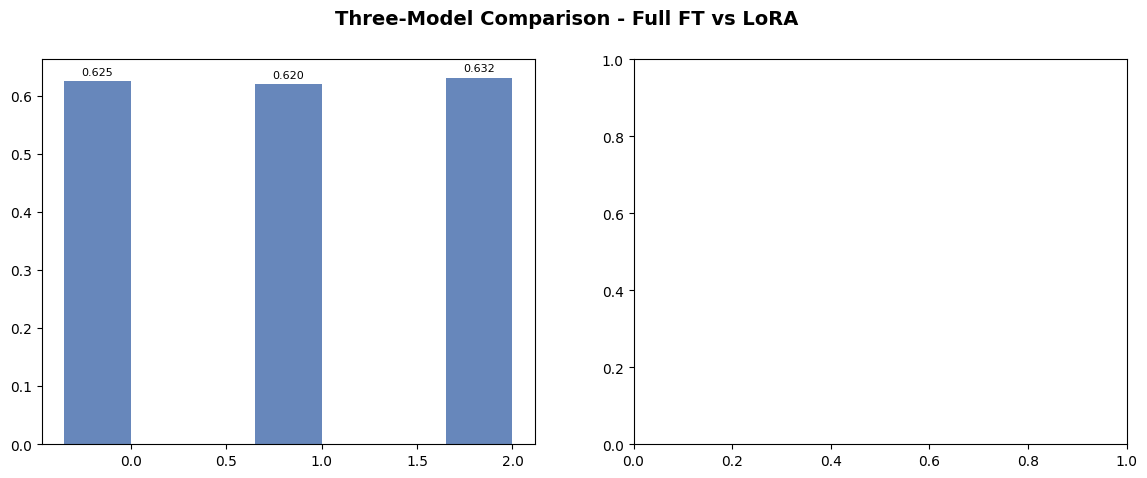

In [32]:
# Bar chart of comparison: Accuracy & F1-Macro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Three-Model Comparison - Full FT vs LoRA", fontsize=14, fontweight="bold")

models = list(MODELS.keys())
x = np.arange(len(models))
width = 0.35
palette = {"Full FT": "#4C72B0", "LoRA": "#DD8452"}

for ax, (metric_col, metric_label) in zip(
    axes,
    [("eval_accuracy", "Accuracy"), ("eval_f1_macro", "F1-Macro")]
):
    for method, offset in zip(["Full FT", "LoRA"], [-width / 2, width / 2]):
        vals = [
            r["test_results"][metric_col]
            for r in all_results if r["method"] == method
        ]
        bars = ax.bar(
            x + offset, vals, width,
            label=method, color=palette[method], alpha=0.85,
        )
        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
 
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_label)
    ax.set_ylabel(metric_label)
    ax.legend()

plt.tight_layout()
plt.savefig("./outputs/three_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

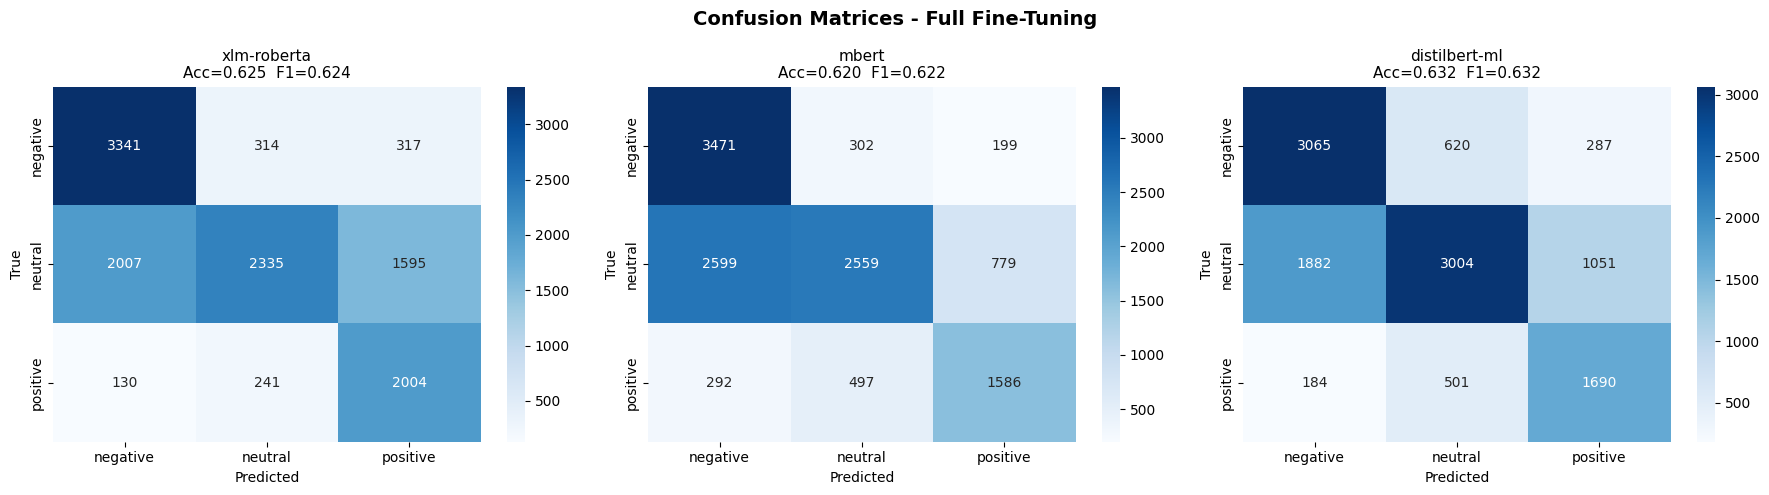

In [33]:
# Confusion Matrix comparison for full ft
full_ft_results = [r for r in all_results if r["method"] == "Full FT"]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices - Full Fine-Tuning", fontsize=14, fontweight="bold")

for ax, r in zip(axes, full_ft_results):
    cm = confusion_matrix(r["true_ids"], r["pred_ids"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=unique_labels, yticklabels=unique_labels, ax=ax,
    )
    acc = r["test_results"]["eval_accuracy"]
    f1  = r["test_results"]["eval_f1_macro"]
    ax.set_title(f"{r['model_key']}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
 
plt.tight_layout()
plt.savefig("./outputs/confusion_matrices_fullft.png", dpi=150, bbox_inches="tight")
plt.show()

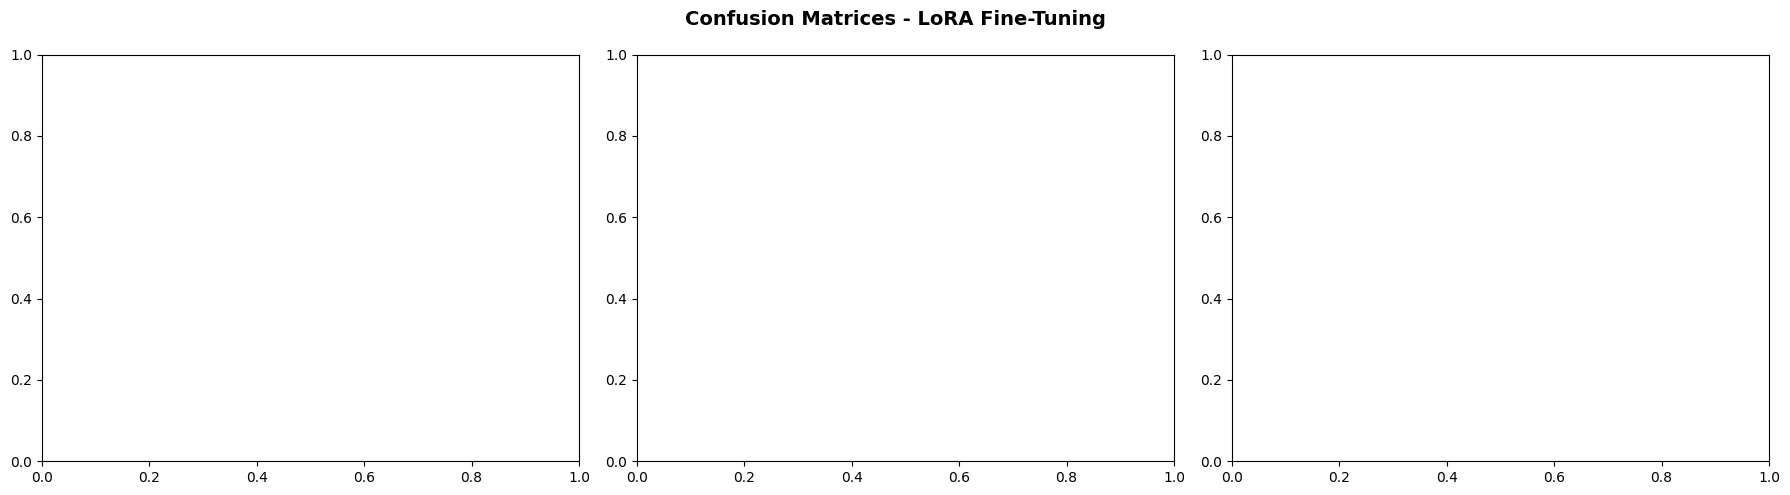

In [34]:
# Confusion Matrix comparison for LoRA
lora_results = [r for r in all_results if r["method"] == "LoRA"]
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices - LoRA Fine-Tuning",
             fontsize=14, fontweight="bold")
 
for ax, r in zip(axes, lora_results):
    cm = confusion_matrix(r["true_ids"], r["pred_ids"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=unique_labels, yticklabels=unique_labels, ax=ax,
    )
    acc = r["test_results"]["eval_accuracy"]
    f1  = r["test_results"]["eval_f1_macro"]
    ax.set_title(f"{r['model_key']}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=11)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
 
plt.tight_layout()
plt.savefig("./outputs/confusion_matrices_lora.png", dpi=150, bbox_inches="tight")
plt.show()

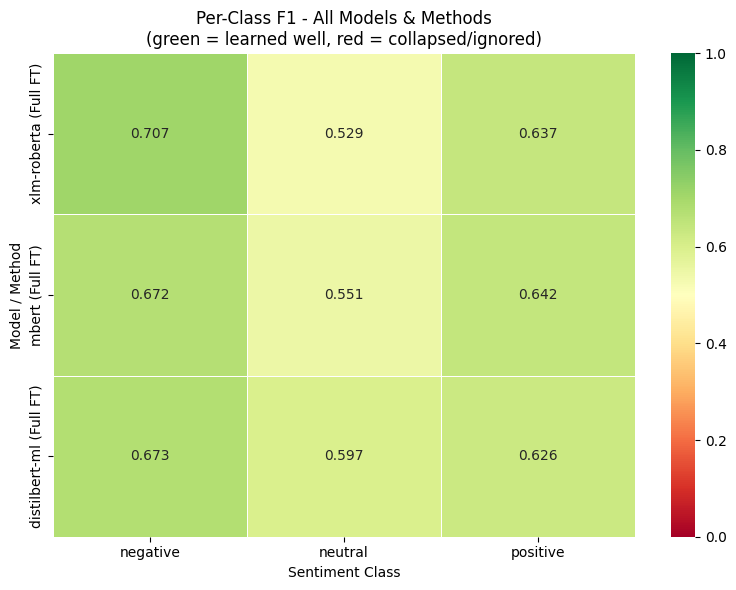

In [35]:
# Per-class F1 heatmap
heatmap_data = {}
for r in all_results:
    key = f"{r['model_key']} ({r['method']})"
    per_class = f1_score(
        r["true_ids"], r["pred_ids"],
        labels=list(range(NUM_LABELS)),
        average=None,
        zero_division=0,
    )
    heatmap_data[key] = per_class
 
heatmap_df = pd.DataFrame(heatmap_data, index=unique_labels).T
 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="RdYlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
)
ax.set_title(
    "Per-Class F1 - All Models & Methods\n"
    "(green = learned well, red = collapsed/ignored)",
    fontsize=12,
)
ax.set_xlabel("Sentiment Class")
ax.set_ylabel("Model / Method")
plt.tight_layout()
plt.savefig("./outputs/per_class_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

-> Poor accuracy was caused by the synthetic text from the dataset.

If we want to improve the accuracy, we better re-consider the dataset.

**Model collapsed for full fine-tuning and LoRA methods.**

for the first experiment, there were not much methods added, plain full ft and LoRA with configs. However, the model collapsed becasue the model could not find singals in the text (not due to the class imbalacne).


## Multi-Lingual Support Analysis

Because our dataset already has language labels, this section is not needed

In [34]:
def safe_detect(text: str) -> str:
    """Detect language; return 'unknown' if detection fails."""
    try:
        return detect(str(text))
    except LangDetectException:
        return "unknown"

# Run on a sample first (full run is in the multilingual section)
sample_detect = df["Text"].sample(min(200, len(df)), random_state=SEED)
detected_langs = sample_detect.apply(safe_detect)

print("Detected language sample distribution:")
print(detected_langs.value_counts().head(10))

Detected language sample distribution:
Text
en    200
Name: count, dtype: int64


Detecting languages (this may take a moment on large datasets)...

Detected 1 unique languages
Top languages:
language
en    2000
Name: count, dtype: int64


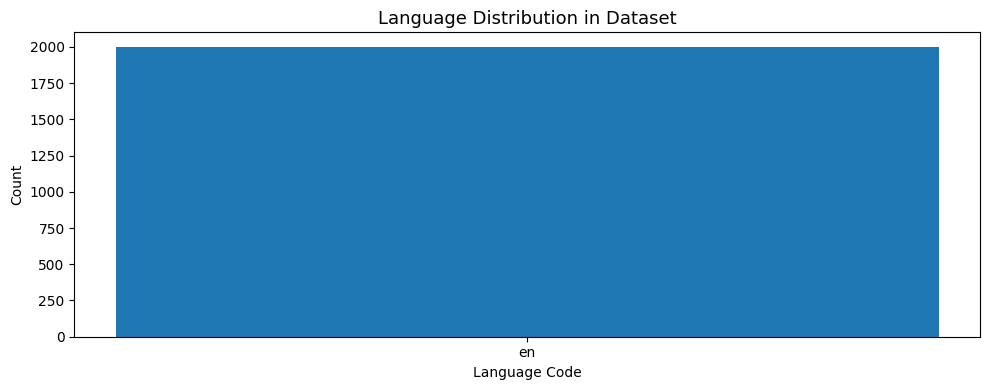

In [35]:
print("Detecting languages (this may take a moment on large datasets)...")
df["language"] = df["Text"].apply(safe_detect)

lang_dist = df["language"].value_counts()
print(f"\nDetected {len(lang_dist)} unique languages")
print("Top languages:")
print(lang_dist.head(15))

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
top_langs = lang_dist.head(10)
ax.bar(top_langs.index, top_langs.values, color=sns.color_palette("tab10", 10))
ax.set_title("Language Distribution in Dataset", fontsize=13)
ax.set_xlabel("Language Code")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Kafka
To be added after analysis of baseline (NLP LSTM based models)